# **Dataset Deret Waktu untuk Prediksi**

---


Mengambil Data NO₂ Sentinel-5P untuk Daerah Manyar lewat openEO
Kode berikut dipakai untuk mendapatkan data konsentrasi Nitrogen Dioksida (NO₂) dari satelit Sentinel-5P dengan menggunakan layanan openEO. Data ini digunakan untuk mengevaluasi kualitas udara di area Manyar selama periode tertentu.

Langkah-langkah proses:

1. Autentikasi ke openEO Langkah pertama yaitu melakukan autentikasi ke endpoint openeo. dataspace. copernicus. eu dengan memanfaatkan metode OIDC (OpenID Connect) agar dapat mengakses dataset dari Sentinel-5P.

2. Identifikasi Area Tertentu (AOI) AOI (area yang dianalisis) ditetapkan sebagai poligon yang berisi koordinat lintang dan bujur yang meliputi wilayah Manyar. Area ini menjadi fokus utama dalam pengambilan data.

3. Panggilan Koleksi Data Sentinel-5P Koleksi SENTINEL_5P_L2 dimuat dengan rentang waktu tertentu (seperti dari tanggal mulai hingga tanggal akhir) dan area pembatas (bounding box) sedikit lebih luas dari AOI. Ini dilakukan untuk memperhitungkan resolusi spasial dari Sentinel-5P yang sekitar ±7 km.

4. Agregasi Temporal (Rata-rata Harian) Mengingat data dari Sentinel-5P mungkin tersedia beberapa kali dalam satu hari, proses agregasi temporal dilakukan dengan menghitung rata-rata per hari untuk mendapatkan nilai harian NO₂.

5. Agregasi Spasial Berdasarkan AOI Rata-rata nilai NO₂ kemudian dihitung sesuai dengan area AOI yang telah ditetapkan, yaitu daerah Manyar.

6. Pelaksanaan Batch dan Penyimpanan Hasil Proses pengolahan dilakukan sebagai tugas batch di server openEO, dan hasil akhirnya disimpan dalam format NetCDF (. nc) agar bisa dipakai untuk analisis lebih lanjut, seperti pemodelan deret waktu (time series) atau prediksi mengenai kualitas udara.

In [1]:
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 335.1/335.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.10.1
    Uninstalling xarray-2025.10.1:
      Successfully uninstalled xarray-2025.10.1


In [2]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

aoi = {
    "type": "Polygon",
        "coordinates": [
        [
            [
                112.61,
                -7.15
            ],
            [
                112.61,
                -7.15
            ],
            [
                112.61,
                -7.15
            ],
            [
                112.61,
                -7.15
            ],
            [
                112.61,
                -7.15
            ]
        ]
    ],
    "type": "Polygon"
}

s5p_no2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-15", "2025-10-19"],
    spatial_extent={
        "west": 113.45,
        "south": -7.25,
        "east": 114.05,
        "north": -6.75
    },
    bands=["NO2"]
)

s5p_no2_daily = s5p_no2.aggregate_temporal_period(
    period="day",
    reducer="mean"
)

s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    geometries=aoi,
    reducer="mean"
)

job = s5p_no2.execute_batch(title="NO2 in Manyar", outputfile="NO2_in_Manyar.nc")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=EJKE-EJTI 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
0:00:00 Job 'j-2510221407364c399860973f2015cfd2': send 'start'
0:00:13 Job 'j-2510221407364c399860973f2015cfd2': created (progress 0%)
0:00:18 Job 'j-2510221407364c399860973f2015cfd2': created (progress 0%)
0:00:25 Job 'j-2510221407364c399860973f2015cfd2': created (progress 0%)
0:00:33 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:00:43 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:00:55 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:01:11 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:01:30 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:01:54 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:02:24 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:03:02 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:03:49 Job 'j-2510221407364c399860973f2015cfd2': running (progress N/A)
0:04:47 Job 'j-25102214073

## **Membaca Hasil Ekspor NetCDF dan Mengekstrak Variabel NO₂**

---



Setelah data berhasil diambil dari openEO dan disimpan dalam file bernama `NO2_in_Manyar. nc`, langkah selanjutnya adalah membuka file tersebut dan mengambil variabel-variabel yang terdapat di dalamnya.

Format NetCDF (. nc) adalah format umum yang digunakan untuk menyimpan data terkait satelit dan iklim, karena kemampuan mendukung struktur data yang memiliki dimensi lebih dari satu — termasuk data spasial (lintang, bujur) dan temporal (waktu). Untuk membaca file ini, kita akan memanfaatkan pustaka `netCDF4`.

Berikut adalah langkah-langkah yang diperlukan:

1. Membuka file `. nc` dengan `netCDF4. Dataset`
File yang diekspor dibuka sehingga semua informasi metadata dan variabel yang ada dapat diakses.

2. Melihat daftar variabel dalam dataset
Langkah ini penting untuk menemukan variabel yang diperlukan, seperti konsentrasi NO₂ dan variabel waktu yang biasanya bernama `"time"` atau `"t"`.

3. Mengambil data NO₂ dan waktu
Konsentrasi NO₂ dibaca dalam bentuk array multidimensi, sedangkan data waktu umumnya disimpan sebagai nilai offset (misalnya “days since 1970-01-01”).

4. Mengonversi waktu ke format tanggal
Dengan menggunakan atribut `units` pada variabel waktu, nilai offset tersebut dapat diubah menjadi format `datetime` agar lebih mudah dianalisis.

5. Menampilkan cuplikan data
Untuk memastikan bahwa proses pembacaan berjalan dengan baik, beberapa nilai awal dari variabel NO₂ dan waktu akan ditampilkan sebagai contoh.

In [3]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.0 MB/s eta 0:00:00


In [4]:
import netCDF4

file_path = "/content/NO2_in_Manyar.nc"
ds = netCDF4.Dataset(file_path)

print(" Variabel dalam file:")
print(ds.variables.keys())

no2 = ds.variables["NO2"][:]

time = ds.variables["t"][:]

try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time
print("\n📅 Contoh data pertama:")
for i in range(min(10, len(no2))):
    print(f"{dates[i]} | NO2: {no2[i]}")

 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

📅 Contoh data pertama:
2023-10-15 00:00:00 | NO2: [[8.966615496319719e-06 -2.392675241935649e-06 -3.0093137866060715e-06
  1.001477812678786e-05 1.7949954781215638e-05 6.251369086385239e-06
  1.1501825611048844e-05 3.560855475370772e-06 3.647016228569555e-06
  1.4542471035383642e-05 1.032557338476181e-05]
 [3.7396214338514255e-06 4.4958237594983075e-06 -3.0093137866060715e-06
  1.001477812678786e-05 1.1489659300423227e-05 -5.246918135526357e-06
  8.04716364655178e-06 4.42362619423875e-07 1.1687496225931682e-05
  1.4542471035383642e-05 1.032557338476181e-05]
 [8.006143616512418e-06 1.295386755373329e-05 -6.859128461655928e-06
  1.3635681170853786e-05 1.1489659300423227e-05 -5.246918135526357e-06
  6.050181582395453e-06 6.969158675929066e-06 1.0722932529461104e-05
  9.662238880991936e-06 1.5079879631230142e-05]
 [8.006143616512418e-06 1.295386755373329e-05 1.782755134627223e-05
  5.527882422029506e-06 7.848360837670043e-06 5

## **Pengubahan Data NetCDF ke CSV untuk Analisis Lanjutan**


---



Kode yang berikut ini digunakan untuk membaca keluaran data dari Sentinel-5P dengan format NetCDF (. nc) yang sudah diunduh dari layanan openEO untuk daerah Manyar. Pertama-tama, file NO2_in_Manyar. nc dibuka dengan menggunakan pustaka netCDF4, dan kemudian semua variabel yang terdapat di dalamnya ditampilkan untuk memverifikasi ketersediaan data yang dibutuhkan — yaitu variabel waktu ("t") dan konsentrasi NO₂ ("NO2"). Berikutnya, nilai waktu diubah dari format offset (misalnya “days since 1970-01-01”) menjadi format tanggal yang sesungguhnya dengan menggunakan fungsi num2date().

Setelah itu, data konsentrasi NO₂ diekstraksi dan dirata-ratakan secara spasial dengan memanfaatkan fungsi np. nanmean(), sehingga menghasilkan satu nilai rata-rata untuk setiap waktu pengamatan. Data yang telah dirata-rata ini kemudian digabungkan dengan nilai waktu dalam sebuah DataFrame pandas, yang mempermudah proses analisis atau visualisasi lebih lanjut. Terakhir, DataFrame tersebut disimpan ke dalam file dengan format CSV bernama NO2_Manyar. csv, dan beberapa baris awal ditampilkan untuk memastikan bahwa proses konversi dan penyimpanan berjalan sesuai rencana.

In [5]:
import netCDF4
import pandas as pd
import numpy as np

file_path = "/content/NO2_in_Manyar.nc"
ds = netCDF4.Dataset(file_path)

print(ds)

print(ds.variables.keys())

time_var = ds.variables["t"][:]
no2_var = ds.variables["NO2"][:]

time_units = ds.variables["t"].units
dates = netCDF4.num2date(time_var, units=time_units)

if no2_var.ndim > 1:
    no2_mean = np.nanmean(no2_var, axis=tuple(range(1, no2_var.ndim)))
else:
    no2_mean = no2_var

df = pd.DataFrame({
    "time": dates,
    "NO2": no2_mean
})

df.to_csv("/content/NO2_Manyar.csv", index=False)
print(" File NO2_Manyar.csv berhasil dibuat.")
print(df.head())

<class 'netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    Conventions: CF-1.9
    institution: Copernicus Data Space Ecosystem openEO API - 0.68.0a10.dev20250930+2976
    description: 
    title: 
    dimensions(sizes): t(728), y(15), x(11)
    variables(dimensions): int32 t(t), float64 x(x), float64 y(y), |S1 crs(), float32 NO2(t, y, x)
    groups: 
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
 File NO2_Manyar.csv berhasil dibuat.
                  time       NO2
0  2023-10-15 00:00:00  0.000007
1  2023-10-16 00:00:00  0.000013
2  2023-10-17 00:00:00  0.000018
3  2023-10-18 00:00:00  0.000014
4  2023-10-19 00:00:00  0.000014


## **Konversi Data NO₂ Menjadi Format Supervised Learning**

---



Kode berikut ini digunakan untuk menyiapkan dataset deret waktu NO₂ agar bisa diterapkan dalam model prediksi atau pembelajaran mesin. Pertama-tama, file yang diekspor dari NO2_Manyar. csv dibuka dengan menggunakan pandas, kemudian kolom waktu diubah menjadi format tanggal dan dijadikan sebagai indeks waktu. Proses interpolasi dengan cara method='time' dilakukan untuk mengisi nilai yang hilang (NaN) berdasarkan urutan waktunya, sehingga data menjadi lebih kontinu dan siap untuk analisis deret waktu tanpa menghilangkan pola temporal yang ada.

Kemudian, kode ini menciptakan dataset dalam format pembelajaran terawasi dengan menghasilkan fitur lag — yaitu nilai NO₂ dari beberapa hari yang lalu (NO2(t-1), NO2(t-2), dan seterusnya) hingga n_lags = 4. Nilai-nilai lag tersebut digunakan sebagai variabel input untuk memperkirakan nilai NO₂ saat ini (NO2(t)). Setelah kolom-kolom lag telah dibuat, baris yang memiliki nilai NaN akibat pergeseran waktu dihapus agar data bersih dan siap digunakan dalam pelatihan model prediksi. Hasil akhirnya adalah tabel yang terstruktur secara berurutan, memperlihatkan hubungan antara kondisi masa lalu dan kondisi terkini konsentrasi NO₂ di area Manyar.

In [6]:
import pandas as pd

df = pd.read_csv("/content/NO2_Manyar.csv")

df['time'] = pd.to_datetime(df['time'], errors='coerce')

df = df.set_index('time')

df['NO2'] = df['NO2'].interpolate(method='time')

print(df.isna().sum())

n_lags = 4

supervised = pd.DataFrame()

for i in range(n_lags, 0, -1):
    supervised[f'NO2(t-{i})'] = df['NO2'].shift(i)

supervised['NO2(t)'] = df['NO2']

supervised = supervised.dropna()

print("📅 Head of Data:")
print(supervised.head())

print("")
print("📦 Data info:")
supervised.info

NO2    0
dtype: int64
📅 Head of Data:
            NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
time                                                        
2023-10-19  0.000007  0.000013  0.000018  0.000014  0.000014
2023-10-20  0.000013  0.000018  0.000014  0.000014  0.000013
2023-10-21  0.000018  0.000014  0.000014  0.000013  0.000017
2023-10-22  0.000014  0.000014  0.000013  0.000017  0.000015
2023-10-23  0.000014  0.000013  0.000017  0.000015  0.000015

📦 Data info:


<bound method DataFrame.info of             NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
time                                                        
2023-10-19  0.000007  0.000013  0.000018  0.000014  0.000014
2023-10-20  0.000013  0.000018  0.000014  0.000014  0.000013
2023-10-21  0.000018  0.000014  0.000014  0.000013  0.000017
2023-10-22  0.000014  0.000014  0.000013  0.000017  0.000015
2023-10-23  0.000014  0.000013  0.000017  0.000015  0.000015
...              ...       ...       ...       ...       ...
2025-10-14  0.000017  0.000009  0.000011  0.000015  0.000017
2025-10-15  0.000009  0.000011  0.000015  0.000017  0.000012
2025-10-16  0.000011  0.000015  0.000017  0.000012  0.000019
2025-10-17  0.000015  0.000017  0.000012  0.000019  0.000013
2025-10-18  0.000017  0.000012  0.000019  0.000013  0.000015

[724 rows x 5 columns]>

## **Normalisasi Data untuk Model Supervised Learning**

---



Kode berikut digunakan untuk menskalakan data waktu sebelum diterapkan dalam pelatihan model prediksi. Langkah pertama adalah membagi data menjadi dua bagian: variabel fitur (`X`) yang mencakup empat nilai lag NO₂ sebelumnya (`NO2(t-4)` sampai `NO2(t-1)`) dan variabel target (`y`) yang terdiri dari nilai NO₂ yang sekarang (`NO2(t)`). Proses ini sangat penting agar model dapat memahami keterkaitan antara nilai-nilai sebelumnya dan nilai saat ini. Kemudian, digunakan `MinMaxScaler` dari paket `scikit-learn` untuk mengatur skala data ke rentang 0 hingga 1, sehingga setiap fitur berada pada skala yang setara dan tidak ada satu pun yang menguasai model karena perbedaan satuan atau nilai.

Setelah normalisasi selesai, hasil transformasi disimpan dalam variabel `X_scaled` dan dikonversi kembali menjadi DataFrame `normalized_df` dengan nama kolom yang sama seperti sebelumnya agar lebih mudah dibaca dan diproses lebih lanjut. Normalisasi ini sangat krusial dalam algoritma pembelajaran mesin seperti LSTM, RNN, atau regresi linier, karena membantu model untuk konvergen lebih cepat dan meningkatkan stabilitas perhitungan numerik. Bagian akhir dari kode menunjukkan perbandingan antara data sebelum dan sesudah normalisasi untuk memastikan bahwa proses penskalaan dilakukan secara akurat.

In [7]:
from sklearn.preprocessing import MinMaxScaler

X = supervised[['NO2(t-4)', 'NO2(t-3)', 'NO2(t-2)', 'NO2(t-1)']]
y = supervised['NO2(t)']

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

supervised = supervised.reset_index()

normalized_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Sebelum normalisasi:\n", X.head())
print("\nSesudah normalisasi:\n", normalized_df.head())

Sebelum normalisasi:
             NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)
time                                              
2023-10-19  0.000007  0.000013  0.000018  0.000014
2023-10-20  0.000013  0.000018  0.000014  0.000014
2023-10-21  0.000018  0.000014  0.000014  0.000013
2023-10-22  0.000014  0.000014  0.000013  0.000017
2023-10-23  0.000014  0.000013  0.000017  0.000015

Sesudah normalisasi:
    NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)
0  0.410881  0.509829  0.592648  0.515581
1  0.509829  0.592648  0.515581  0.512861
2  0.592648  0.515581  0.512861  0.503735
3  0.515581  0.512861  0.503735  0.571636
4  0.512861  0.503735  0.571636  0.529179


## **Pemodelan Time Series NO₂ Menggunakan K-Nearest Neighbors (KNN) Regressor**

---



Kode berikut dipakai untuk membangun serta menilai model prediksi konsentrasi NO₂ dengan memanfaatkan algoritma K-Nearest Neighbors (KNN) Regressor. Pertama, dataset dibagi menjadi dua segmen, yaitu data latihan (80%) dan data pengujian (20%) dengan memanfaatkan fungsi `train_test_split` tanpa mengacak urutannya (`shuffle=False`) agar urutan waktu tetap terjaga dalam analisis deret waktu. Empat nilai lag sebelumnya (`NO2(t-4)` hingga `NO2(t-1)`) digunakan sebagai fitur input (`X`), sedangkan nilai NO₂ saat ini (`NO2(t)`) berfungsi sebagai target (`y`). Dua versi dari model KNN diuji berdasarkan parameter `weights`, yaitu `"uniform"` (semua tetangga punya bobot yang sama) dan `"distance"` (tetangga yang lebih dekat memiliki bobot lebih besar).

Setelah itu, kode menghitung Root Mean Squared Error (RMSE) dan koefisien determinasi (R²) untuk menilai performa model pada data pengujian. RMSE memberikan gambaran tentang seberapa besar kesalahan rata-rata prediksi dibandingkan dengan nilai sebenarnya, sedangkan R² menunjukkan seberapa efektif model dalam menjelaskan variasi data (nilai yang semakin mendekati 1 menandakan kinerja yang lebih baik). Hasil prediksi dan data sebenarnya kemudian divisualisasikan menggunakan matplotlib, di mana grafik atas menunjukkan model dengan bobot `"uniform"` dan grafik bawah dengan bobot `"distance"`. Visualisasi ini mempermudah analisis kemampuan model KNN dalam mengikuti pola perubahan NO₂ berdasarkan data historis di kawasan Manyar.

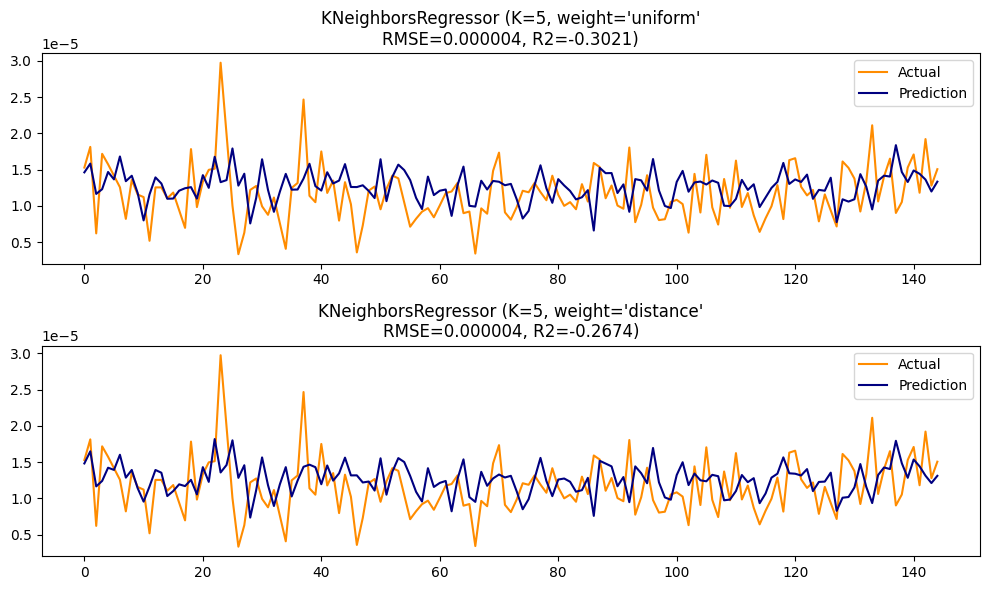

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = supervised[['NO2(t-4)', 'NO2(t-3)', 'NO2(t-2)', 'NO2(t-1)']]
y = supervised['NO2(t)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

n_neighbors = 5

plt.figure(figsize=(10, 6))

for i, weights in enumerate(['uniform', 'distance']):
    knn = neighbors.KNeighborsRegressor(n_neighbors, weights=weights)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    plt.subplot(2, 1, i + 1)
    plt.plot(range(len(y_test)), y_test, 'darkorange', label="Actual")
    plt.plot(range(len(y_pred)), y_pred, 'navy', label="Prediction")
    plt.title(f"KNeighborsRegressor (K={n_neighbors}, weight='{weights}'\nRMSE={rmse:.6f}, R2={r2:.4f})")
    plt.legend()
    plt.tight_layout()

plt.show()